In [2]:
#Notebook for forecasting future prices

!pip install prophet

Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


In [2]:
!pip install yfinance

In [3]:
!pip install statsmodels

In [4]:
#load all the modules
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.metrics import mean_squared_error 
import numpy as np
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
#Note 1: please install prophet using !pip install prophet
#Note 2: please install yfinance using: !pip install yfinance

In [5]:
#step 0: ask for user input for the desired stock symbol of interest and assign it to a variable named "stock_symbol"
#hint: we covered getting user input in the lessons
stock_symbol="AAPL"

In [10]:
stock_symbol = input("Enter the stock symbole : ")

Enter the stock symbole :  TSLA


In [21]:
#step 1: download the historical stock data (last 2 years) of the symbol of interest from Yahoo Finance using the yfinance API
yf_ticker=yf.Ticker(stock_symbol) #
yf_history=yf_ticker.history(start='2023-01-01',end='2024-06-24')

#number of days that we want to forecast
forecast_period=180 

In [22]:
#step 2: print the first 5 rows of the dataset
#hint: use the head() function
#yf_history=yf_history.loc[(yf_history['Date'] >= '2018-07-15') & (yf_history['Date'] <= '2023-07-15')]
yf_history.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2023-01-03 00:00:00-05:00,118.470001,118.800003,104.639999,108.099998,231402800,0.0,0.0
2023-01-04 00:00:00-05:00,109.110001,114.589996,107.519997,113.639999,180389000,0.0,0.0
2023-01-05 00:00:00-05:00,110.510002,111.750000,107.160004,110.339996,157986300,0.0,0.0
2023-01-06 00:00:00-05:00,103.000000,114.389999,101.809998,113.059998,220911100,0.0,0.0
2023-01-09 00:00:00-05:00,118.959999,123.519997,117.110001,119.769997,190284000,0.0,0.0


In [23]:
#step 3: create a data frame called "yf_mod" with only the Close columns from the yf_history data frame
#hint: select the desired columns by using the column names. e.g. my_data_fram[["Column"]]
yf_mod=yf_history[["Close"]]

In [24]:
#step 4: Reset the column index and rename the Date and Close columns as ds and y
yf_mod.reset_index(level=0,inplace=True)
yf_mod=yf_mod.rename({'Date':'ds','Close':'y'},axis='columns')
yf_mod.head()

,ds,y
0,2023-01-03 00:00:00-05:00,108.099998
1,2023-01-04 00:00:00-05:00,113.639999
2,2023-01-05 00:00:00-05:00,110.339996
3,2023-01-06 00:00:00-05:00,113.059998
4,2023-01-09 00:00:00-05:00,119.769997


In [27]:
#Step 5: split the yf_mod data frame into training and test data frames. We will use the training data frame to build the model and test data frame for forecasting.
#We will use the last 180 days for testing purposes and the remaining dataset for training.
#hint: first count the number of rows of yf_mod using the len() or yf_mod.shape commands
#hint 2: use the iloc function in pandas to select the desired number of rows
number_rows=len(yf_mod)
yf_mod['ds'] = yf_mod['ds'].dt.tz_localize(None)
yf_mod_train=yf_mod

In [28]:
number_rows=len(yf_mod)
yf_mod_train=yf_mod



In [29]:
# step 5.1 Run Default Prophet
m1 = Prophet(daily_seasonality=True)

m1.fit(yf_mod_train)

yf_mod_test = m1.make_future_dataframe(periods=forecast_period)


prophet_forecast_1=m1.predict(yf_mod_test)

print("Model 1 RMSE default min forecast: ",prophet_forecast_1[["trend"]][(number_rows-forecast_period):(number_rows)].min())
print("Model 1 RMSE default mean forecast: ",prophet_forecast_1[["trend"]][(number_rows-forecast_period):(number_rows)].mean())
print("Model 1 RMSE default max forecast: ",prophet_forecast_1[["trend"]][(number_rows-forecast_period):(number_rows)].max())


11:01:31 - cmdstanpy - INFO - Chain [1] start processing
11:01:31 - cmdstanpy - INFO - Chain [1] done processing


Model 1 RMSE default min forecast:  trend    130.217915
dtype: float64
Model 1 RMSE default mean forecast:  trend    173.797356
dtype: float64
Model 1 RMSE default max forecast:  trend    216.762379
dtype: float64


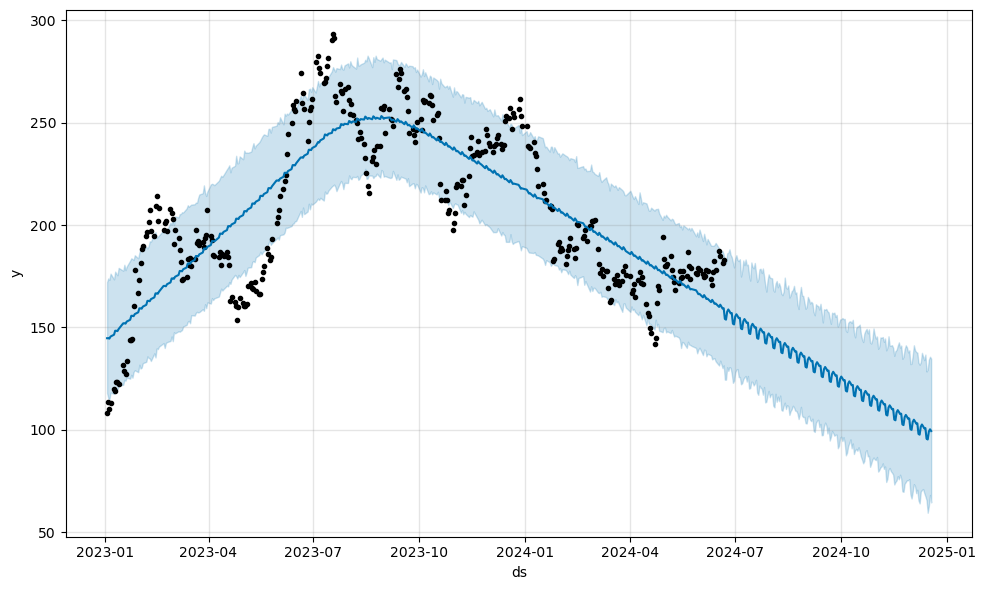

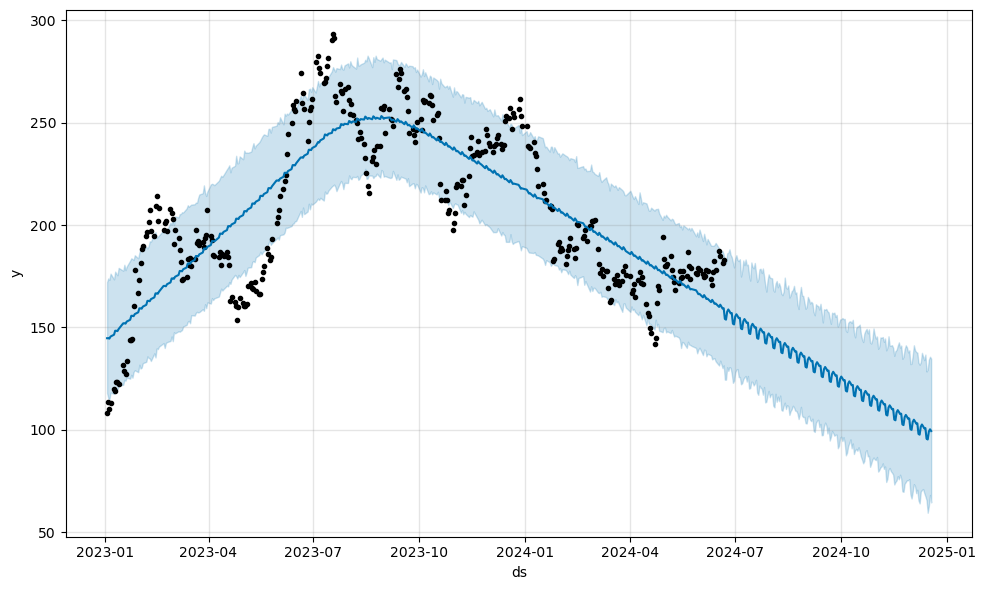

In [30]:
#use the plot function in prophet to visualize the time series
m1.plot(prophet_forecast_1)

In [18]:

# step 5.2 Run Prophet with tuned parameters
m2 = Prophet(changepoint_prior_scale=0.01 ,
                        seasonality_prior_scale=0.001,
                      seasonality_mode = 'multiplicative',
                      
                      daily_seasonality = True,
                   
                      interval_width=0.95)

m2.fit(yf_mod_train)

yf_mod_test = m2.make_future_dataframe(periods=forecast_period)


prophet_forecast_2=m2.predict(yf_mod_test)

print("Model 2 Prophet tuned min forecast: ",prophet_forecast_2[["trend"]][(number_rows-forecast_period):(number_rows)].min())
print("Model 2 Prophet tuned mean forecast: ",prophet_forecast_2[["trend"]][(number_rows-forecast_period):(number_rows)].mean())
print("Model 2 Prophet tuned max forecast: ",prophet_forecast_2[["trend"]][(number_rows-forecast_period):(number_rows)].max())


10:57:51 - cmdstanpy - INFO - Chain [1] start processing
10:57:51 - cmdstanpy - INFO - Chain [1] done processing


Model 2 Prophet tuned min forecast:  trend    178.604786
dtype: float64
Model 2 Prophet tuned mean forecast:  trend    206.6863
dtype: float64
Model 2 Prophet tuned max forecast:  trend    234.732111
dtype: float64


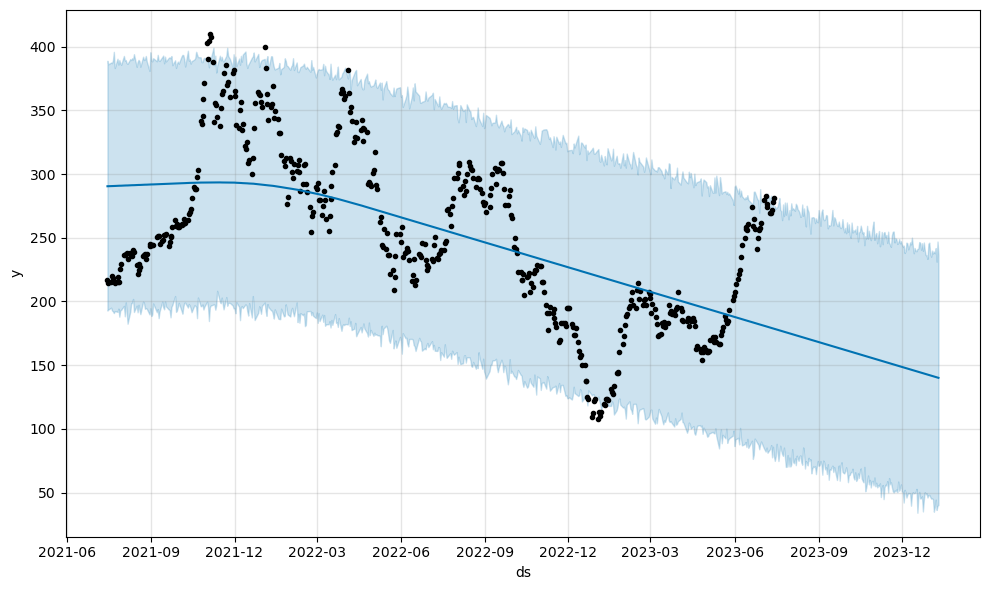

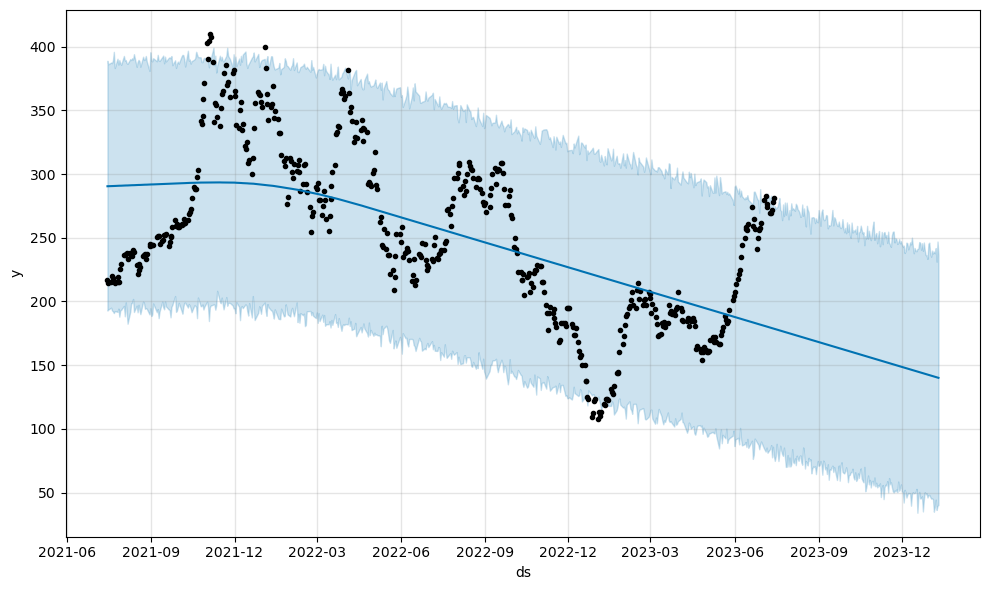

In [31]:
#use the plot function in prophet to visualize the time series
m2.plot(prophet_forecast_2)

In [19]:
#step 5.3: run ARIMA (auto-regressive integrated moving average) model - a time-series forecasting approach
#we will create a function to get forecasted prices from the ARIMA model
def get_arima(train,period,arima_order=(0,0,0)):
    arima_model=ARIMA(train,order=arima_order)
    arima_fit=arima_model.fit()
    arima_pred=arima_fit.forecast(period)
    return arima_pred

arima_forecast1=get_arima(yf_mod_train[["y"]],period=forecast_period)

predicted=arima_forecast1

print("Model 3 ARIMA min forecast: ",arima_forecast1.min())
print("Model 3 ARIMA mean forecast: ",arima_forecast1.mean())
print("Model 3 ARIMA max forecast: ",arima_forecast1.max())


arima_forecast2=get_arima(yf_mod_train[["y"]],period=forecast_period,arima_order=(1,2,2))

predicted=arima_forecast2

print("Model 4 ARIMA tuned min forecast: ",arima_forecast2.min())
print("Model 4 ARIMA tuned mean forecast: ",arima_forecast2.mean())
print("Model 4 ARIMA tuned max forecast: ",arima_forecast2.max())


Model 3 ARIMA min forecast:  251.03205727720135
Model 3 ARIMA mean forecast:  251.0320572772014
Model 3 ARIMA max forecast:  251.03205727720135


C:\Users\karan\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\karan\anaconda3\lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


Model 4 ARIMA tuned min forecast:  281.430369739754
Model 4 ARIMA tuned mean forecast:  292.9866115606476
Model 4 ARIMA tuned max forecast:  304.5058365739647
